##Ejercicio2


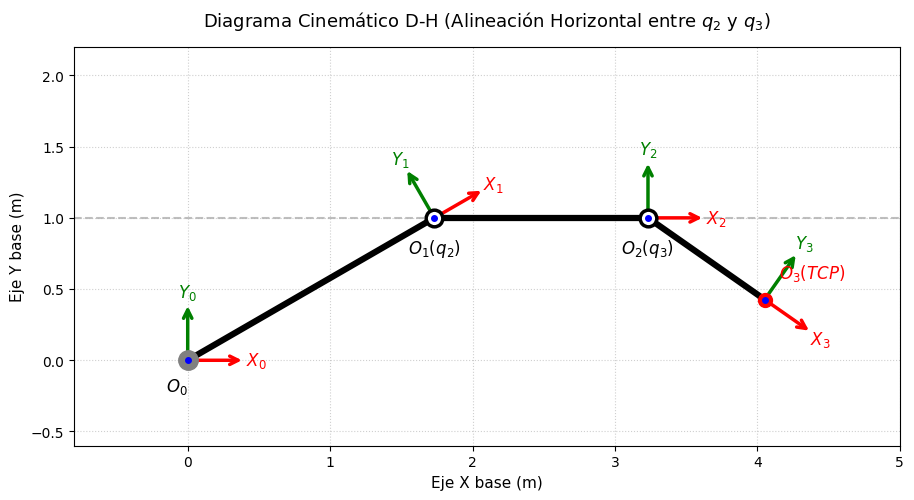

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Longitudes de eslabones
l1, l2, l3 = 2.0, 1.5, 1.0

q1 = np.radians(30)
q2 = np.radians(-30)
q3 = np.radians(-35)

# Posiciones de los orígenes de cada marco
O0 = np.array([0.0, 0.0])
O1 = O0 + np.array([l1 * np.cos(q1), l1 * np.sin(q1)])
O2 = O1 + np.array([l2 * np.cos(q1 + q2), l2 * np.sin(q1 + q2)])
O3 = O2 + np.array([l3 * np.cos(q1 + q2 + q3), l3 * np.sin(q1 + q2 + q3)])

# Configuración de la figura
fig, ax = plt.subplots(figsize=(10, 5))

# Línea de referencia horizontal entre O1 (q2) y O2 (q3)
ax.axhline(y=O1[1], color='gray', linestyle='--', alpha=0.5, zorder=1)

# Dibujo de eslabones
ax.plot([O0[0], O1[0]], [O0[1], O1[1]], 'k-', lw=4.5, zorder=2)
ax.plot([O1[0], O2[0]], [O1[1], O2[1]], 'k-', lw=4.5, zorder=2)
ax.plot([O2[0], O3[0]], [O2[1], O3[1]], 'k-', lw=4.5, zorder=2)

# Dibujo de articulaciones
ax.plot(O0[0], O0[1], 'o', color='gray', ms=14, zorder=5)
ax.plot(O1[0], O1[1], 'o', color='white', mec='black', mew=2.5, ms=12, zorder=5)
ax.plot(O2[0], O2[1], 'o', color='white', mec='black', mew=2.5, ms=12, zorder=5)
ax.plot(O3[0], O3[1], 'ro', ms=10, zorder=5)

# Función para dibujar marcos D-H
def draw_frame(ax, origin, angle, label_id, scale=0.4):
    x_dir = np.array([np.cos(angle), np.sin(angle)])
    y_dir = np.array([-np.sin(angle), np.cos(angle)])

    x_axis = origin + scale * x_dir
    y_axis = origin + scale * y_dir

    # Eje X_i
    ax.annotate('', xy=x_axis, xytext=origin,
                arrowprops=dict(arrowstyle='->', color='red', lw=2.5, mutation_scale=15))
    ax.text(x_axis[0] + 0.08 * x_dir[0], x_axis[1] + 0.08 * x_dir[1],
            f'$X_{label_id}$', color='red', fontsize=12, weight='bold', va='center', ha='center')

    # Eje Y_i
    ax.annotate('', xy=y_axis, xytext=origin,
                arrowprops=dict(arrowstyle='->', color='green', lw=2.5, mutation_scale=15))
    ax.text(y_axis[0] + 0.08 * y_dir[0], y_axis[1] + 0.08 * y_dir[1],
            f'$Y_{label_id}$', color='green', fontsize=12, weight='bold', va='center', ha='center')

    # Indicador de Eje Z_i
    ax.plot(origin[0], origin[1], 'o', color='blue', ms=4, zorder=6)

# Dibujo de sistemas {0}, {1}, {2}, {3}
draw_frame(ax, O0, 0, '0')
draw_frame(ax, O1, q1, '1')
draw_frame(ax, O2, q1 + q2, '2')
draw_frame(ax, O3, q1 + q2 + q3, '3')

# Etiquetas de orígenes y articulaciones
ax.text(O0[0]-0.15, O0[1]-0.22, '$O_0$', fontsize=12, weight='bold')
ax.text(O1[0], O1[1]-0.25, '$O_1 (q_2)$', fontsize=12, weight='bold', ha='center')
ax.text(O2[0], O2[1]-0.25, '$O_2 (q_3)$', fontsize=12, weight='bold', ha='center')
ax.text(O3[0]+0.1, O3[1]+0.15, '$O_3 (TCP)$', fontsize=12, color='red', weight='bold')

# Ajustes de ejes
ax.set_aspect('equal')
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_title('Diagrama Cinemático D-H (Alineación Horizontal entre $q_2$ y $q_3$)', fontsize=13, pad=15)
ax.set_xlabel('Eje X base (m)', fontsize=11)
ax.set_ylabel('Eje Y base (m)', fontsize=11)

ax.set_xlim([-0.8, 5.0])
ax.set_ylim([-0.6, 2.2])

plt.tight_layout()
plt.show()

##Ejercicio3

In [ ]:
import numpy as np
import sympy as sp

def dh_matrix_symbolic(theta, d, a, alpha):
    """Calcula la matriz homogénea D-H simbólica usando SymPy."""
    ct, st = sp.cos(theta), sp.sin(theta)
    ca, sa = sp.cos(alpha), sp.sin(alpha)

    return sp.Matrix([
        [ct, -st * ca,  st * sa, a * ct],
        [st,  ct * ca, -ct * sa, a * st],
        [ 0,       sa,       ca,      d],
        [ 0,        0,        0,      1]
    ])

def dh_matrix_numeric(theta, d, a, alpha):
    """Calcula la matriz homogénea D-H numérica usando NumPy."""
    ct, st = np.cos(theta), np.sin(theta)
    ca, sa = np.cos(alpha), np.sin(alpha)

    return np.array([
        [ct, -st * ca,  st * sa, a * ct],
        [st,  ct * ca, -ct * sa, a * st],
        [ 0,       sa,       ca,      d],
        [ 0,        0,        0,      1]
    ], dtype=float)

def fk_chain(dh_table, mode='numeric'):
    """Calcula la cinemática directa multiplicando la cadena de matrices D-H."""
    if mode == 'numeric':
        T_total = np.eye(4)
        for theta, d, a, alpha in dh_table:
            T_total = T_total @ dh_matrix_numeric(theta, d, a, alpha)
        return T_total
    else:
        T_total = sp.eye(4)
        for theta, d, a, alpha in dh_table:
            T_total = T_total * dh_matrix_symbolic(theta, d, a, alpha)
        return sp.simplify(T_total)

if __name__ == "__main__":
    # Parámetros de prueba
    theta1 = np.radians(45)
    d1 = 0.35
    a1 = 0.15
    alpha1 = np.radians(-90)

    #1. Generación de Matriz Numérica y Extracción de R y p
    T = dh_matrix_numeric(theta1, d1, a1, alpha1)
    R = T[:3, :3]
    p = T[:3, 3]

    # 2. Validaciones Matemáticas
    I_3 = np.eye(3)
    norm_frobenius = np.linalg.norm(R.T @ R - I_3, 'fro')
    det_diff = abs(np.linalg.det(R) - 1.0)

    p_esperado = np.array([a1 * np.cos(theta1), a1 * np.sin(theta1), d1])
    error_p = np.linalg.norm(p - p_esperado)

    #3. Verificación de Tolerancias (< 10^-15)
    val_ortogonalidad = norm_frobenius < 1e-15
    val_determinante = det_diff < 1e-15
    val_posicion = error_p < 1e-15

    print("RESULTADOS DE VALIDACIÓN CINEMÁTICA")
    print(f"Norma de Frobenius ||R^T * R - I||_F : {norm_frobenius:.2e} -> Sumple (< 10^-15): {val_ortogonalidad}")
    print(f"Diferencia de Determinante |det(R) - 1|: {det_diff:.2e} -> Cumple (< 10^-15): {val_determinante}")
    print(f"Vector p Calculado : {p}")
    print(f"Vector p Teórico   : {p_esperado}")
    print(f"Error Vectorial ||p - p_teorico||      : {error_p:.2e} -> Cumple (< 10^-15): {val_posicion}")

RESULTADOS DE VALIDACIÓN CINEMÁTICA
Norma de Frobenius ||R^T * R - I||_F : 1.43e-17 -> Sumple (< 10^-15): True
Diferencia de Determinante |det(R) - 1|: 0.00e+00 -> Cumple (< 10^-15): True
Vector p Calculado : [0.10606602 0.10606602 0.35      ]
Vector p Teórico   : [0.10606602 0.10606602 0.35      ]
Error Vectorial ||p - p_teorico||      : 0.00e+00 -> Cumple (< 10^-15): True
